In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import time
import copy

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle, Circle
from matplotlib.ticker import FormatStrFormatter
import tomlkit

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import cupy as cp
cp.cuda.Device(3).use()

import warnings
warnings.filterwarnings("ignore")

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, wfe

import esc_llowfsc_sim
import esc_llowfsc_sim.esc_fraunhofer as esc

from magpyx.utils import ImageStream

model_path = esc_llowfsc_sim.path/'data/2k-256/'
# model_path = esc_llowfsc_sim.path/'data/1k-256/'
# model_path = esc_llowfsc_sim.path/'data/large/2k-512/'
# model_path = esc_llowfsc_sim.path/'data/large/2k-512/'
# model_path = esc_llowfsc_sim.path/'data/large/1k-512/'
with open(model_path/'model_params.toml', mode="r",) as fp:
    params = tomlkit.load(fp).unwrap()
model_params = params['model']

/opt/conda/envs/llowfscSim310/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import pylablib. NKT laser functionality not available.


1.8786530165499975e-08
Generated frequency vector with sampling of 2.78e-04Hz and maximum frequency of 5.00e+02Hz.
Generating time series for WFE mode 1.
	RMS of generated knee PSD: 1.879e-08
	RMS of generated time series: 1.879e-08 RMS
Generating time series for WFE mode 2.
	RMS of generated knee PSD: 1.879e-08
	RMS of generated time series: 1.879e-08 RMS
Generating time series for WFE mode 3.
	RMS of generated knee PSD: 1.000e-09
	RMS of generated time series: 1.002e-09 RMS
Generating time series for WFE mode 4.
	RMS of generated knee PSD: 1.000e-09
	RMS of generated time series: 1.002e-09 RMS
Generating time series for WFE mode 5.
	RMS of generated knee PSD: 1.000e-09
	RMS of generated time series: 1.002e-09 RMS
Generating time series for WFE mode 6.
	RMS of generated knee PSD: 1.000e-09
	RMS of generated time series: 1.002e-09 RMS
Generating time series for WFE mode 7.
	RMS of generated knee PSD: 1.000e-09
	RMS of generated time series: 1.002e-09 RMS
Generating time series for WFE 

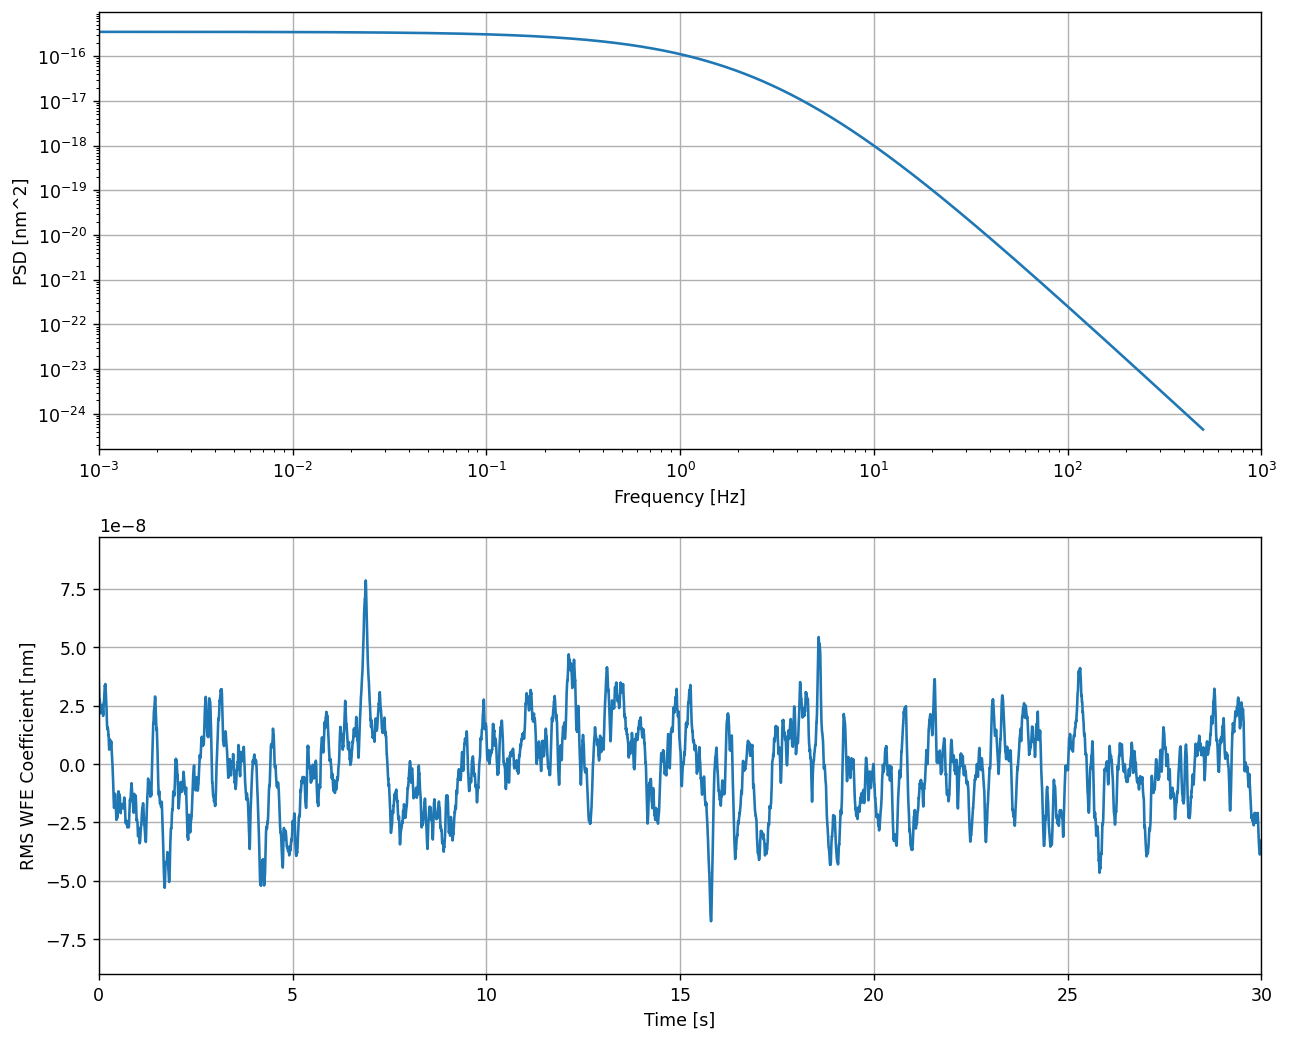

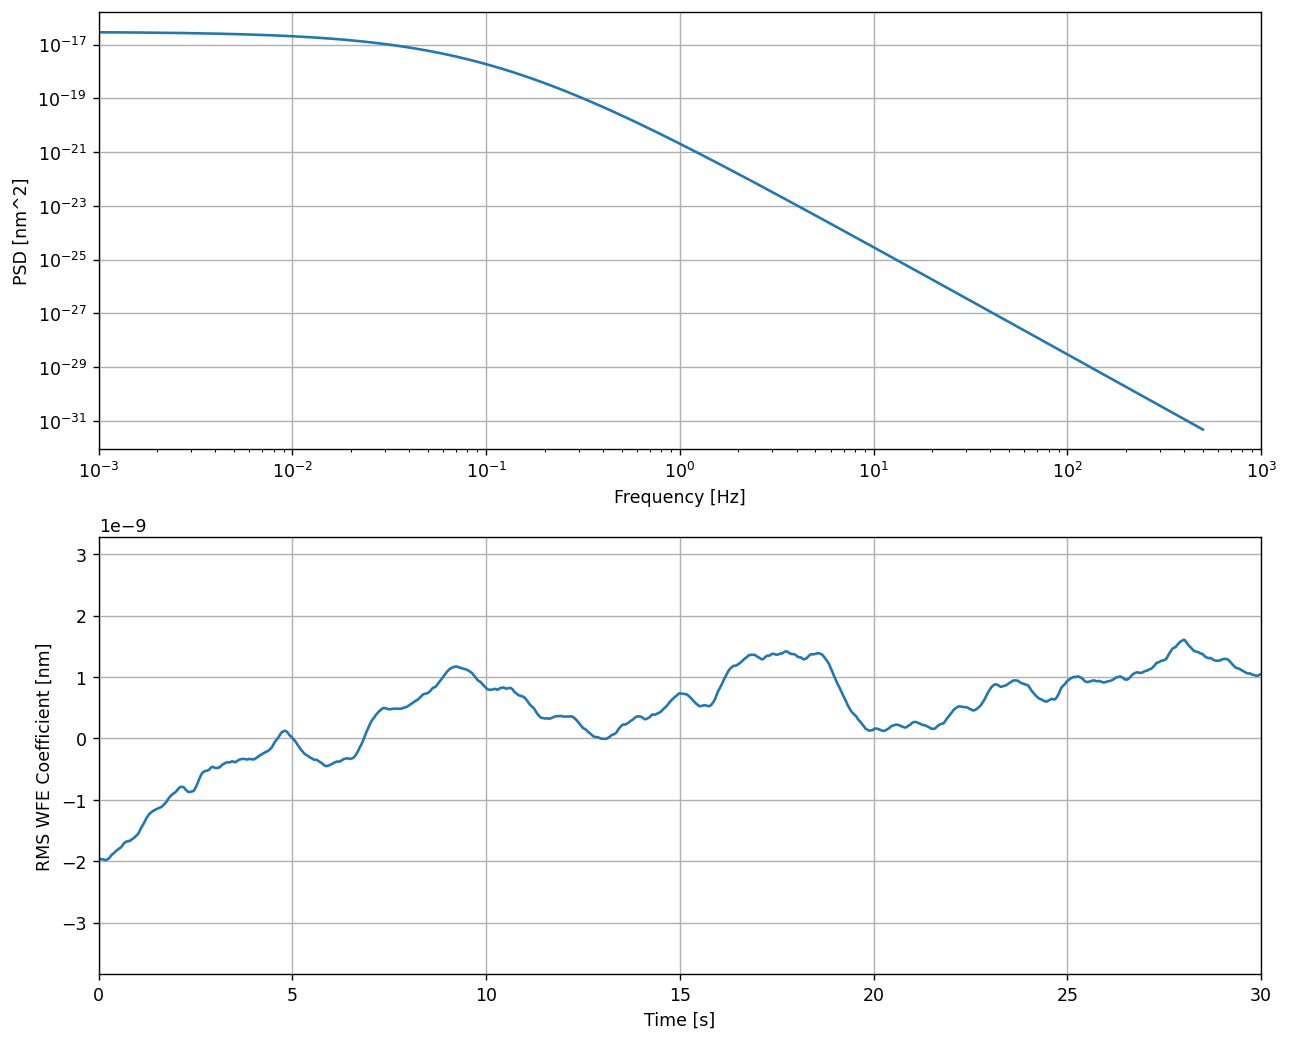

In [39]:
reload(wfe)

temp_sampling = 1e-3
tmax_for_psd = 3600

los_jitter_mas = 5
los_jitter_rms = utils.tt_as_to_rms(los_jitter_mas/1000, model_params["total_pupil_diam"])
los_jitter_fknee = 3
print(los_jitter_rms)

z3_z10_amp_rms = 1e-9
z3_z10_fknee = 0.1

wfe_modes_rms = np.array(2*[los_jitter_rms] + 8*[z3_z10_amp_rms])
f_knees = np.array(2*[los_jitter_fknee] + 8*[z3_z10_fknee])
psd_slope = 4

N_wfe_modes = len(wfe_modes_rms)
wfe_modes = utils.create_zernike_modes(M.APERTURE, nmodes=N_wfe_modes, remove_modes=1)

freqs, delf, times = wfe.generate_freqs(
    delt=temp_sampling, 
    tmax=tmax_for_psd, 
    verbose=True,
)

wfe_psds = xp.zeros((N_wfe_modes, len(freqs)))
wfe_time_series = xp.zeros((N_wfe_modes, len(times)))
seeds = 123 + np.linspace(0, N_wfe_modes-1, N_wfe_modes).astype(int)

for i in range(N_wfe_modes):
# for i in range(3):
    print(f'Generating time series for WFE mode {i+1}.')
    psd = wfe.roll_psd(
        freqs,
        wfe_modes_rms[i],
        f_knees[i],
        psd_slope,
        verbose=True, 
    )
    wfe_psds[i] = copy.copy(psd)

    time_series, times = wfe.generate_time_series(
        psd,
        freqs,
        seed=1234+i,
        # plot=True,
        verbose=True,
    )

    sign = 1 if xp.random.randn(1)>0 else -1
    time_series *= sign
    wfe_time_series[i] = copy.copy(time_series)

    if i==0 or i==2:
        fig, axs = plt.subplots(nrows=2, ncols=1, dpi=125, figsize=(12,10))

        np_freqs = ensure_np_array(freqs)
        np_psd = ensure_np_array(psd)
        np_times = ensure_np_array(times)
        np_time_series = ensure_np_array(time_series)

        series_ylims = 1.2*np.array([-np.max(np.abs(np_time_series)), np.max(np.abs(np_time_series))])

        axs[0].loglog(np_freqs, np_psd)
        axs[0].set_xlim(0.001, 1000)
        axs[0].set_ylabel('PSD [nm^2]')
        axs[0].set_xlabel('Frequency [Hz]')
        axs[0].grid()

        axs[1].plot(np_times, np_time_series)
        axs[1].set_xlim(0, 30)
        # axs[1].set_ylim(series_ylims)
        axs[1].set_ylabel('RMS WFE Coefficient [nm]')
        axs[1].set_xlabel('Time [s]')
        axs[1].grid()

np_wfe_time_series = ensure_np_array(wfe_time_series)

In [4]:
%%timeit
OPD_STREAM.write(np.array([np_wfe_time_series[:, 50]]))

8.76 μs ± 65.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [40]:
opd_vals = np.zeros((10))
opd_vals[2] = -10e-9
OPD_STREAM.write(np.array([opd_vals]))

In [41]:
OPD_STREAM.write(np.zeros((1,10)))

In [17]:
np_wfe_time_series.shape

(10, 3600000)

In [37]:
OPD_STREAM = ImageStream('opdsim')

In [ ]:
CYCLETIME = temp_sampling

try:
    print('Continuously updating OPD SHMIM ...')
    
    t0 = time.perf_counter()  # Time ref point
    time_counter = 0.0

    i = 0
    while 1:
        if i==wfe_time_series.shape[1]-1: 
            i = 0
        OPD_STREAM.write(np.array([np_wfe_time_series[:, i]]))
        i+=1
        # print([np_wfe_time_series[:, i]])
        
        now = time.perf_counter()
        elapsed_time = now - t0
        target_time = time_counter + CYCLETIME
        if elapsed_time < target_time:
            time.sleep(target_time - elapsed_time)

        # In the full program we write to a csv but in this simple program we will just print it
        # milliseconds_since_epoch = datetime.now(timezone.utc)
        # print(milliseconds_since_epoch)

        time_counter += CYCLETIME
except KeyboardInterrupt:
    OPD_STREAM.write(np.zeros(OPD_STREAM.shape).T)
    print('OPD updates terminated.')


Continuously updating OPD SHMIM ...


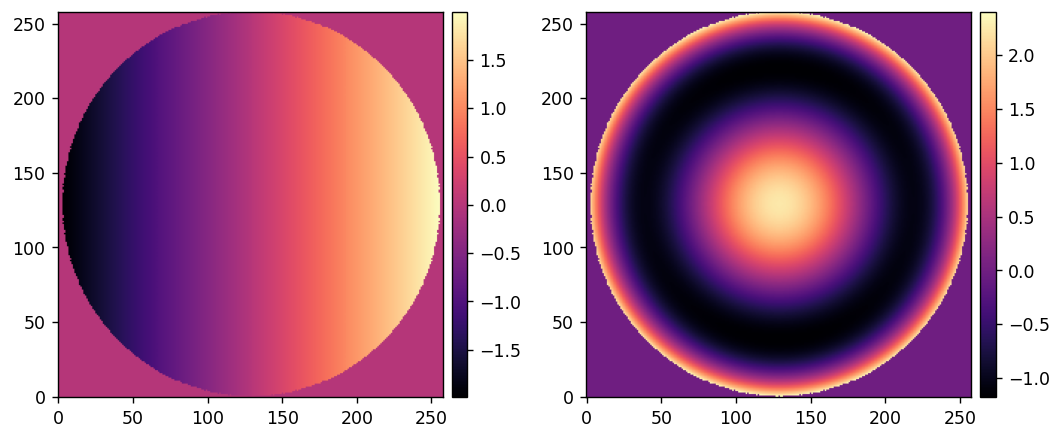

In [25]:
utils.imshow(
    [wfe_modes[0], wfe_modes[-1]]
)